# 🧮— Grouping Data

📂 `tips.csv` and `Titanic-Dataset.csv` — keep both in this folder.

Yesterday: one filter per group. Ten groups meant ten filters.
Today: one line, any number of groups.

In [1]:
import pandas as pd
import numpy as np

titanic = pd.read_csv('/Users/shailesh/Desktop/vedam_Sem3_ml/Data/Titanic-Dataset.csv')              
tip = pd.read_csv('/Users/shailesh/Desktop/vedam_Sem3_ml/Data/tip.csv')     

print(tip.shape, titanic.shape)

(244, 7) (891, 12)




> **Which passenger paid the highest fare in each class, and what was their name?**



---
## 1️⃣ Which day earns the most tips?

```python
df.groupby('column')                    # split
df.groupby('column').size()             # rows per group
df.groupby('column')['other'].mean()    # one number per group
```

In [ ]:

tip.groupby('day')

A plan, not a result. Pandas has split the rows and is waiting for instructions.

**📐 Board.**

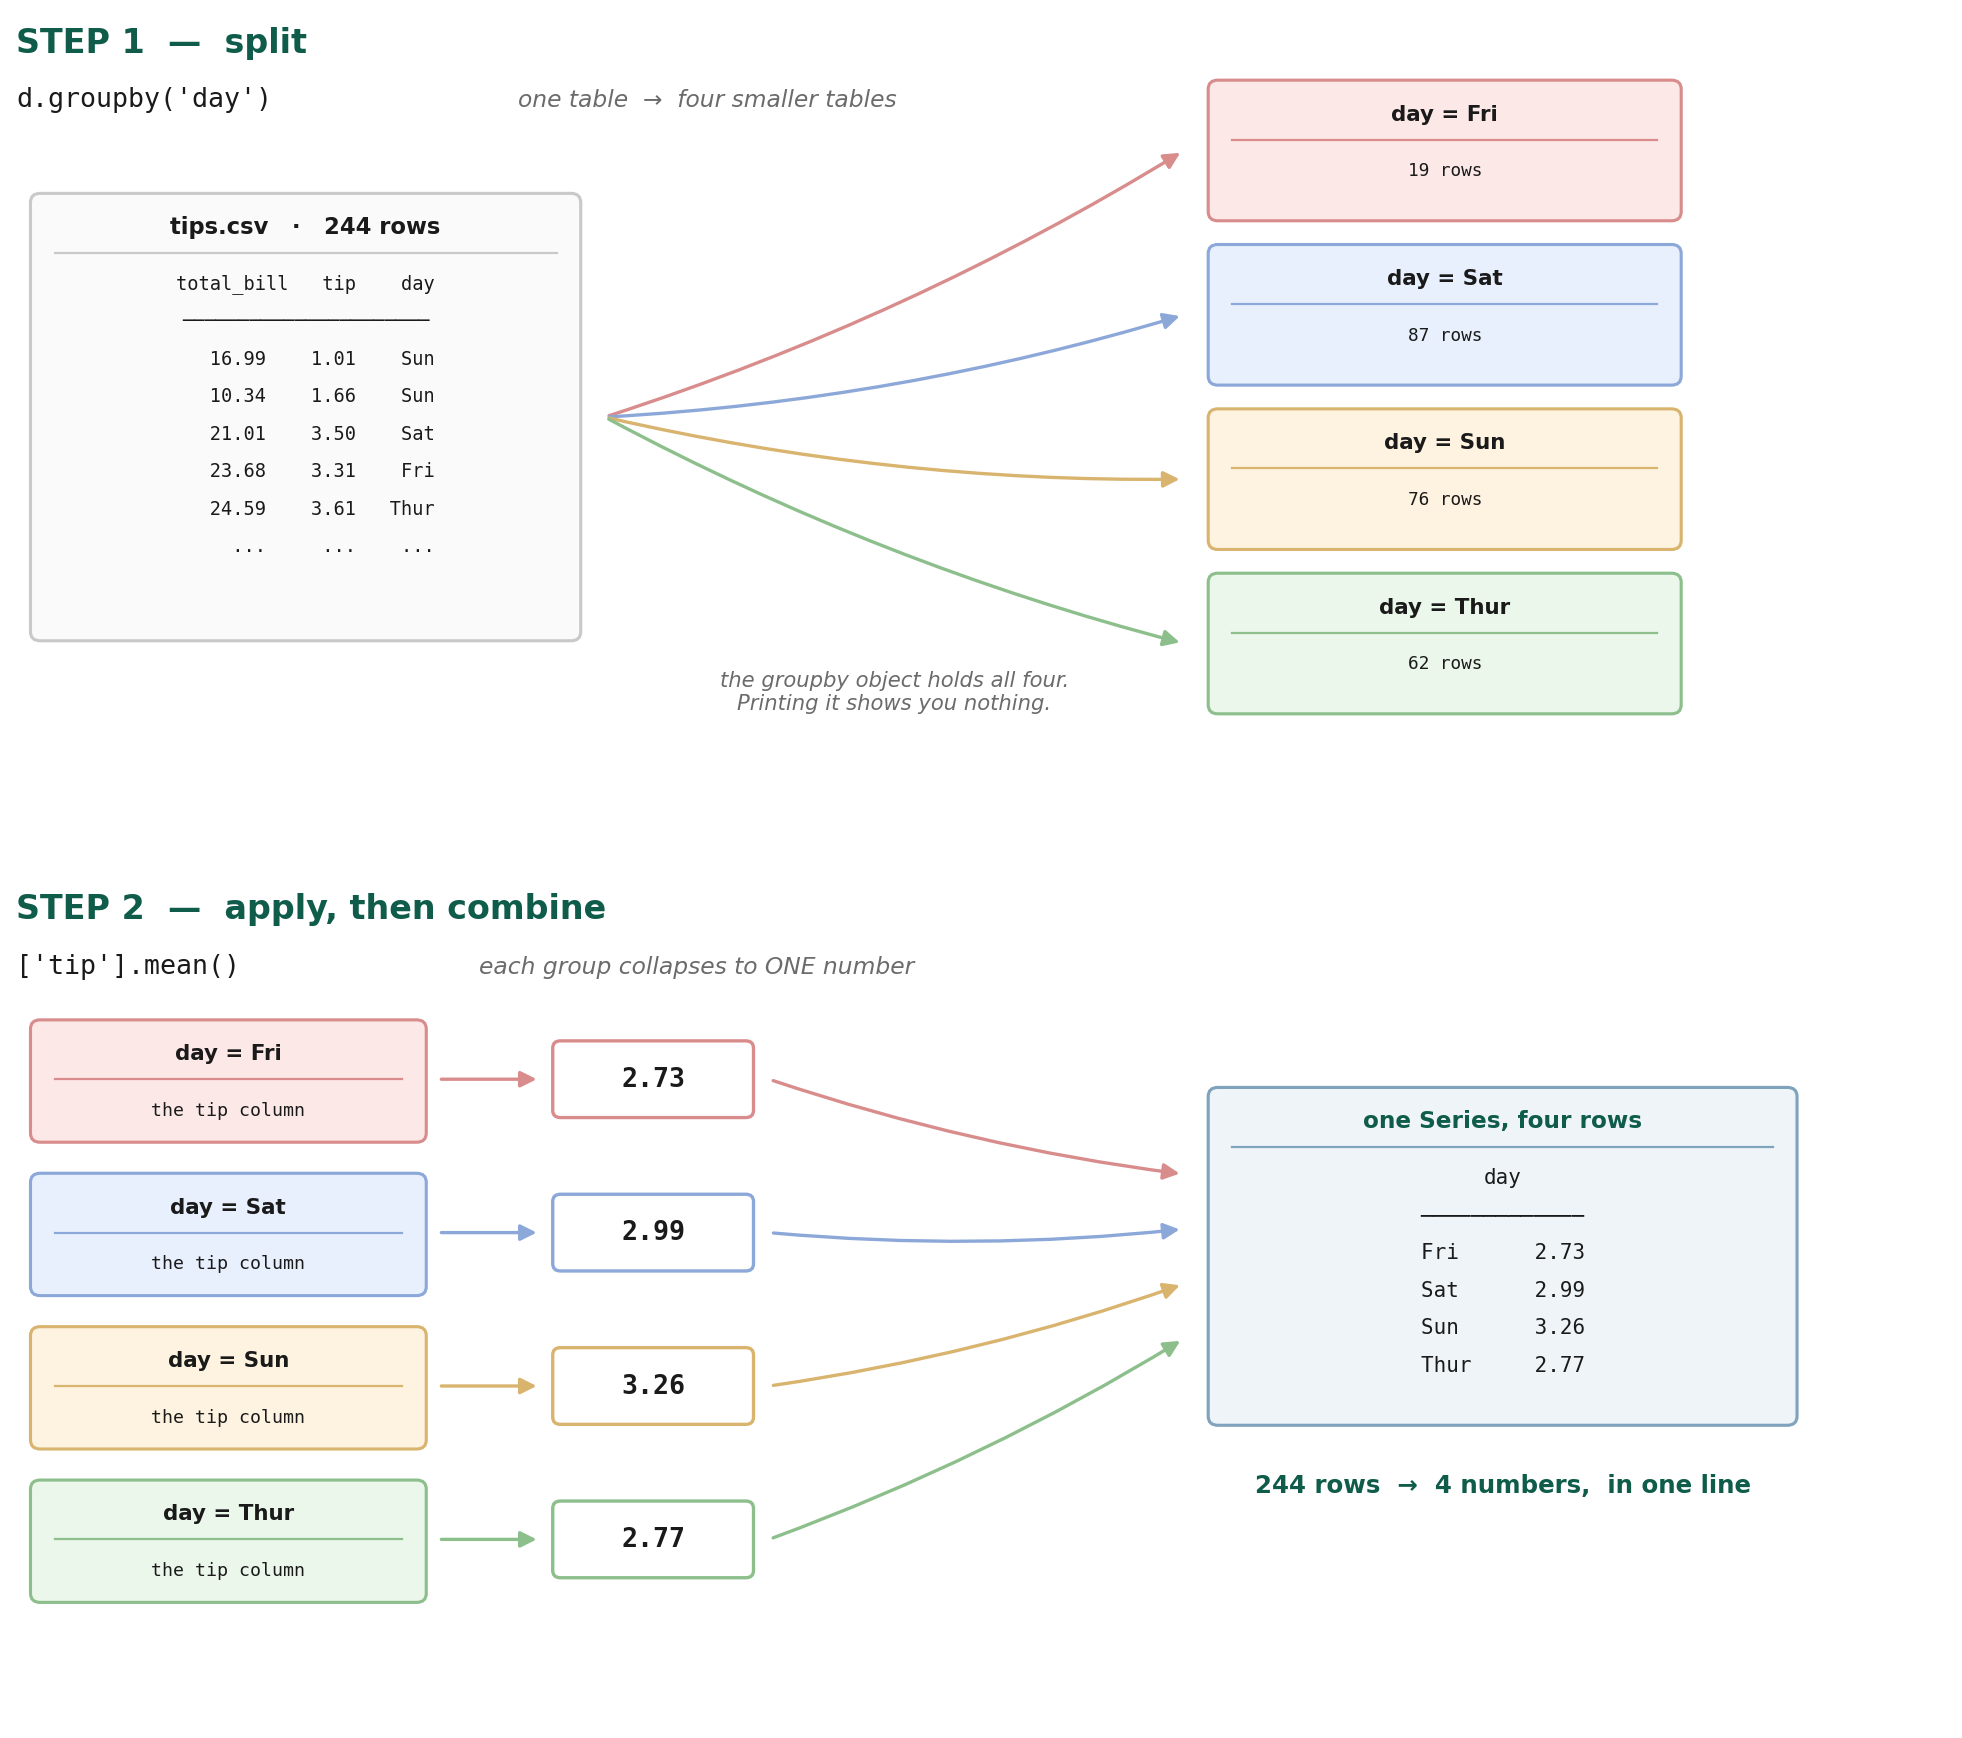

In [ ]:
# how many bills on each day

# tip.groupby("day").size()

tip.groupby("day")['tip'].mean().round(2)

day
Fri     2.73
Sat     2.99
Sun     3.26
Thur    2.77
Name: tip, dtype: float64

In [ ]:
# average tip on each day


| day | bills | avg tip |
|---|---|---|
| Fri | 19 | 2.73 |
| Sat | 87 | 2.99 |
| Sun | 76 | **3.26** |
| Thur | 62 | 2.77 |

Sunday wins. But "biggest tip" and "most generous" are different questions.

In [ ]:
# make a tip_pct column, then average it per day
tip['tip_pct']=round(tip['tip']/tip['total_bill']*100,2)
tip.head(2)
tip.groupby('day')['tip_pct'].mean().round(2)

day
Fri     16.99
Sat     15.31
Sun     16.69
Thur    16.13
Name: tip_pct, dtype: float64

| day | avg tip | avg tip % |
|---|---|---|
| Fri | 2.73 | **17.0** |
| Sat | 2.99 | 15.3 |
| Sun | **3.26** | 16.7 |
| Thur | 2.77 | 16.1 |

Sunday collects the most money. Friday tips at the best rate.

---
### 📝 The 3-step recipe — write this down

```python
d.groupby('day')['tip'].mean()
#      1. group   2. pick  3. apply
```

| step | what | on which column |
|---|---|---|
| **1 Group** | `.groupby('day')` | a **category** column |
| **2 Pick** | `['tip']` | a **number** column |
| **3 Apply** | `.mean()` | `mean sum min max count median` |



In [15]:
tip.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.94
1,10.34,1.66,Male,No,Sun,Dinner,3,16.05
2,21.01,3.50,Male,No,Sun,Dinner,3,16.66
3,23.68,3.31,Male,No,Sun,Dinner,2,13.98
4,24.59,3.61,Female,No,Sun,Dinner,4,14.68


In [ ]:
tip.groupby('day').mean(numeric_only=True)["tip"]
tip.groupby('day')['tip'].mean()



,total_bill,tip,size,tip_pct
day,,,,
Fri,17.151579,2.734737,2.105263,16.991579
Sat,20.441379,2.993103,2.517241,15.314598
Sun,21.410000,3.255132,2.842105,16.689605
Thur,17.682742,2.771452,2.451613,16.126452


In [ ]:
tip.groupby('day')['tip'].mean() 

---
### ⚖️ Two ways — which one runs?

```python
d.groupby('day').mean()['tip']      # A — aggregate everything, then pick
d.groupby('day')['tip'].mean()      # B — pick, then aggregate
```

Guess first, then run both.

In [ ]:
# A

In [ ]:
# B

**A crashes.** It tries to average `sex`, `smoker` and `time` as well.


**B computes exactly one.**

⭐ Always pick before you aggregate.

Bigger table, bigger bill. What happens to the tip **percentage** as the party grows —
up, down, or flat?

In [26]:
tip.groupby('size')['tip_pct'].mean().round(1)

size
1    21.7
2    16.6
3    15.2
4    14.6
5    14.2
6    15.6
Name: tip_pct, dtype: float64

In [ ]:
df["tip_pct"]=df["tip"]/df["total_bill"]*100

In [ ]:
# average tip_pct for each party size
df.groupby("day")['tip_pct'].mean().round(2)

In [ ]:
df.head(1)

In [28]:
# average bill for each party size
tip.groupby('size')['total_bill']

| party size | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|
| avg bill | 7.24 | 16.45 | 23.28 | 28.61 | 30.07 | 34.83 |
| **avg tip %** | **21.7** | 16.6 | 15.2 | 14.6 | **14.1** | 15.6 |

Bill nearly five-doubles, tip rate falls by a third. Hence the automatic service charge
on large groups.

### 🧩 Try these — on the **Titanic** file

In [31]:
titanic.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


**1.1** The company report calls first class *"somewhat safer."* Find the survival rate of
each class and say in one line whether "somewhat" is honest.

In [33]:
titanic.groupby('Pclass')["Survived"].mean().round(2)*100

Pclass
1    63.0
2    47.0
3    24.0
Name: Survived, dtype: float64

**1.2** Average `Fare` paid in each class.

In [35]:
titanic.groupby('Pclass')["Fare"].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

**1.3** Passengers per boarding port, and the average age of each group.

In [ ]:
# 1.3

In [30]:
tip.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.94
1,10.34,1.66,Male,No,Sun,Dinner,3,16.05
2,21.01,3.50,Male,No,Sun,Dinner,3,16.66
3,23.68,3.31,Male,No,Sun,Dinner,2,13.98
4,24.59,3.61,Female,No,Sun,Dinner,4,14.68


Compare all three with the person next to you. Different numbers = one of you grouped wrong.

---
## 2️⃣ Can I trust a group average?

```python
df.groupby('col').size()             # rows
df.groupby('col')['other'].count()   # non-blank values
```

In [ ]:
# bills per day, both ways


Identical — `tips.csv` has no blanks.

⚠️ That's luck, not a rule.

### 🧩 Try these — on the **Titanic** file

**2.1** Per class: number of passengers next to number of ages recorded. Explain the gap. ⭐

```python
pd.DataFrame({'passengers': ____, 'ages_recorded': ____})
```

In [ ]:
# 2.1

**2.2** Same idea per boarding port, using **cabins** recorded. Which port stands out?

In [ ]:
# 2.2

---
## 3️⃣ Two questions at once

Pass a **list**.

```python
df.groupby(['col1','col2'])['value'].mean()
df.groupby(['col1','col2'])['value'].mean().reset_index()   # flat table
```

In [ ]:
# bills for each day AND time


```
Fri  Dinner 12   Sat  Dinner 87
     Lunch   7   Sun  Dinner 76
Thur Dinner  1   Thur Lunch  61
```

**Thursday: one dinner.** You found that by filtering in Day 4. Here all six fall out at once.

In [ ]:
# average bill for each day AND time

In [ ]:
# flatten it — groups become real columns

Grouped results keep the groups in the **index**. `reset_index()` makes them columns again.

### 🧩 Try these — on the **Titanic** file

**3.1** Survival rate for all six `Sex` × `Pclass` groups. Read the top and bottom aloud. ⭐

In [ ]:
# 3.1

**3.2** Turn 3.1 into a normal DataFrame with three columns. What shape?

In [ ]:
# 3.2


### ⭐ 3.3 — when a group average lies

| port | survived |
|---|---|
| Cherbourg | **55.4%** |
| Queenstown | 39.0% |
| Southampton | 33.7% |

Looks like Cherbourg was safer. **Test it** — group by port **and** class, and count how many
of each class boarded where.

In [ ]:
# 3.3

Cherbourg was **50.6% first class**. Queenstown was **93.5% third class**.

The port saved nobody — it was who could afford to board there. ⭐

---
## 🕐 The question we held

> **Which passenger paid the highest fare in each class?**

`.max()` gives the value. `.idxmax()` gives the **row label** — and `.loc` takes labels.

```python
df.loc[ df.groupby('group_col')['value_col'].idxmax() ]
```

In [ ]:
# the postponed question

Same recipe. Only the aggregate changed — you wanted the row, not the number. ⭐

---
## 🏠 Take these home

**H1** Among passengers under 18: survival rate **and** number of children per class.
Does *"women and children first"* hold in every class?

**H2** Make an `age_group` column (`'child'` under 18, else `'adult'`), then group by
`age_group` **and** `Sex`. Did being a child help boys and girls equally?

**H3** Make a `family` column (`SibSp + Parch`). Survival rate **and** group size for each
family size. Check both columns before believing any percentage. ⭐

**H4** On `tips.csv`: which `day` + `time` combination has the highest average tip percentage,
and how many bills is that built on?

**H5** Using `idxmax`, find the oldest passenger in each class — name and age.

---
## 📌 Recap

```python
d.groupby('day').size()                       # rows per group
d.groupby('day')['tip'].mean()                # group, pick, apply
d.groupby(['day','time'])['tip'].mean()       # two columns -> a list
d.groupby('day')['tip'].mean().reset_index()  # groups back to columns
t.loc[t.groupby('Pclass')['Fare'].idxmax()]   # the ROW, not the value
```

| | counts | ignores blanks |
|---|---|---|
| `.size()` | every row | no |
| `.count()` | non-blank values | yes |

⭐ Pick the column **before** you aggregate.
⭐ Read the group **size** next to the group **average**.
⭐ A group average can point at the wrong cause — check with a second column.

**🔜 Next:** `.agg()` — mean, median and count in one line.

---
## 🧠 Exit quiz — write your answers, I'll ask four of you

1. The three steps of the recipe, in order?
2. Why does `groupby('day').mean()['tip']` crash?
3. `.size()` and `.count()` agreed on tips. When would they disagree?
4. Cherbourg had the highest survival rate. Why is "board at Cherbourg" the wrong conclusion?

In [ ]:
# quiz answers